# Uticaj šuma i strategija predobrade teksta na performanse modela za detekciju clickbait naslova

**Clickbait** je stil naslova koji “mami klik” korišćenjem šablonskih fraza, emocionalnih okidača, interpunkcije (?!), brojeva (“7 things…”), ALL CAPS i sl.

U kontekstu **kvaliteta tekstualnih podataka**, clickbait je odličan primer jer jasno pokazuje:
- šum (HTML, višak razmaka, emotikoni, nepotrebni simboli) **vs** signal (?!, brojevi, fraze),
- specifičan vokabular i kratke tekstove,
- stilističke obrasce koji se mogu detektovati jednostavnim modelima.

**Cilj notebook-a:** empirijski ispitati kako različite strategije predobrade utiču na performanse modela zasnovanog na TF-IDF reprezentaciji i linearnom klasifikatoru.

*importovanje biblioteka*

In [51]:
import re
import unicodedata
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

# 1. Učitavanje i osnovni opis skupa podataka

U ovom delu učitavamo skup podataka i radimo osnovnu proveru (sanity check) pre bilo kakve preobrade.

In [52]:
df = pd.read_csv("clickbait_data.csv")

#snapshot podataka
df.head()

,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer Is Here To Give You Chills",1
3,"This Vine Of New York On ""Celebrity Big Brother"" Is Fucking Perfect",1
4,A Couple Did A Stunning Photo Shoot With Their Baby After Learning She Had An Inoperable Brain Tumor,1


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headline   32000 non-null  object
 1   clickbait  32000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.1+ KB


In [54]:
df.shape

(32000, 2)

Ovaj dataset ima 32000 redova i 2 kolone - 1 kolona je naslov druga je binarni identifikator da li je naslov clickbait ili ne

In [55]:
df.describe()

,clickbait
count,32000.000000
mean,0.499969
std,0.500008
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [56]:
# broj duplikata po headline koloni
duplicate_count = df.duplicated(subset=["headline"]).sum()

print("Broj duplikata po headline koloni:", duplicate_count)

Broj duplikata po headline koloni: 0


In [57]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
headline     0
clickbait    0
dtype: int64


Nema nedostajućih vrednosti i nema duplikata.

# 2. EDA kvaliteta teksta

Nakon osnovne valudacije skupa podataka, sledeće na redu je analiza kvaliteta tekstualnih podataka

## 2.0 Class distribution

Pre analize karakteristika teksta potrebno je ispitati raspodelu klasa u skupu podataka. 
Neuravnotežen skup podataka može dovesti do pristrasnosti modela i uticati na interpretaciju rezultata klasifikacije.

In [58]:
class_counts = df["clickbait"].value_counts()
class_percent = df["clickbait"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
clickbait
0    16001
1    15999
Name: count, dtype: int64

Class percentages:
clickbait
0    50.003125
1    49.996875
Name: proportion, dtype: float64


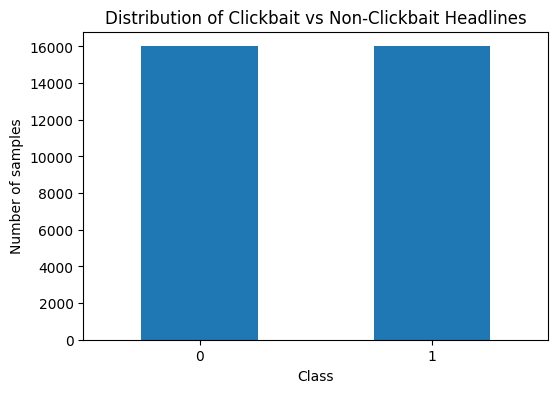

In [59]:
plt.figure(figsize=(6,4))

class_counts.plot(kind="bar")

plt.title("Distribution of Clickbait vs Non-Clickbait Headlines")
plt.xlabel("Class")
plt.ylabel("Number of samples")

plt.xticks(rotation=0)

plt.show()

Rezultati pokazuju raspodelu clickbait i non-clickbait naslova u skupu podataka. 
Relativno uravnotežena raspodela klasa je poželjna jer omogućava modelu da uči obrasce obe klase bez značajne pristrasnosti.

## 2.1 Analiza dužine naslova

In [60]:
# dužina u karakterima
df["char_length"] = df["headline"].str.len()

# dužina u tokenima (reči)
df["token_length"] = df["headline"].str.split().str.len()

df[["char_length", "token_length"]].describe()

,char_length,token_length
count,32000.000000,32000.000000
mean,53.797063,9.065156
std,14.771455,2.603603
min,6.000000,1.000000
25%,44.000000,7.000000
50%,52.000000,9.000000
75%,63.000000,11.000000
max,135.000000,26.000000


- Kao što možemo videti, prosečna dužina naslova iznosi oko **54 karaktera** i oko **9 tokena (reči)**
- Minimalna dužina je 1 token dok je maksimalna **26 tokena**
- Većina naslova (između 25% i 75% percentila) nalazi se u rasponu od **7 do 11 tokena**

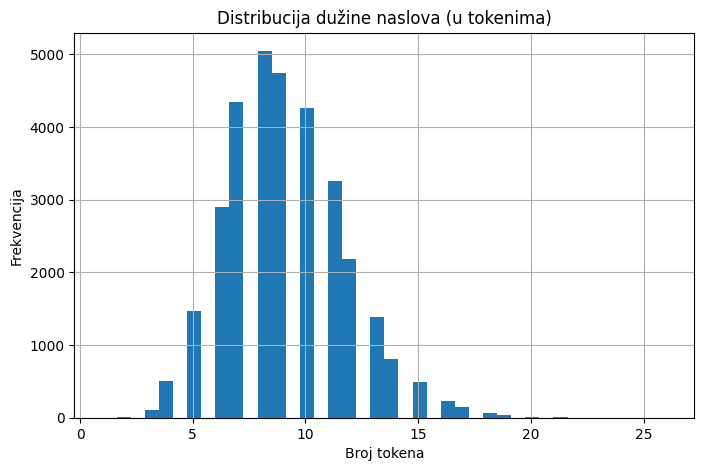

In [61]:
plt.figure(figsize=(8,5))
df["token_length"].hist(bins=40)
plt.title("Distribucija dužine naslova (u tokenima)")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.show()

- Histogram prikazuje da je distribucija dužine naslova približno unimodalna, sa najvećom frekvencijom u opsegu od 7 do 10 tokena.
- Uočava se blaga desna simetrija, što znači da postoji manji broj dužih naslova, dok je većina naslova oko prosečne vrednosti.
- Ekstremno kratki naslovi (1-3) tokena javljaju se retko, dok naslovi duži od 20 tokena predstavljaju mali procenat ukupnog skupa.

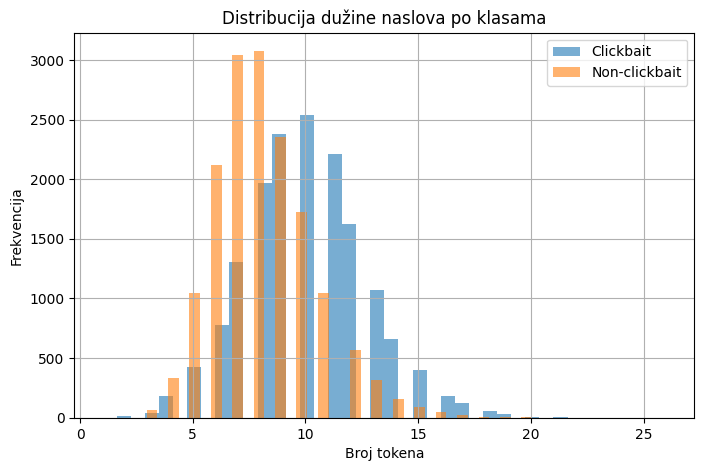

In [62]:
plt.figure(figsize=(8,5))

df[df["clickbait"] == 1]["token_length"].hist(
    bins=40, alpha=0.6, label="Clickbait"
)

df[df["clickbait"] == 0]["token_length"].hist(
    bins=40, alpha=0.6, label="Non-clickbait"
)

plt.legend()
plt.title("Distribucija dužine naslova po klasama")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.show()

Ovaj plot pokazuje jasnu razliku u dužini između clickbait i non-clickbait naslova.
- Clickbait naslovi imaju tendenciju da budu nešto duži od non-clickbait, sa većom frekvencijom u opsegu od 8 do 12 tokena
- Non-clickbait naslovi su najfrekventniji za vrednosti od 5 do 9 tokena
- Duži naslovi gotovo u potpunosti pripadaju clickbait naslovima

=> Ovo ukazuje da dužina naslova može predstavljati *informativnu karakteristiku* za klasifikaciju.

**Preciznija analiza:**

In [63]:
df.groupby("clickbait")["token_length"].describe()

,count,mean,std,min,25%,50%,75%,max
clickbait,,,,,,,,
0,16001.0,8.188613,2.224814,2.0,7.0,8.0,9.0,21.0
1,15999.0,9.941809,2.659194,1.0,8.0,10.0,12.0,26.0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5580\2841562527.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


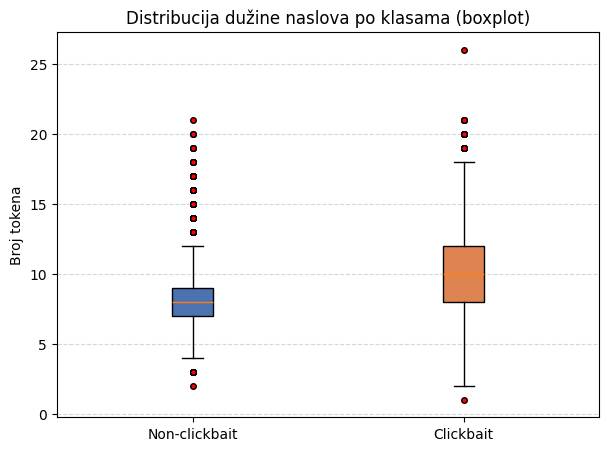

In [64]:
clickbait_lengths = df[df["clickbait"] == 1]["token_length"]
non_clickbait_lengths = df[df["clickbait"] == 0]["token_length"]

plt.figure(figsize=(7,5))

box = plt.boxplot(
    [non_clickbait_lengths, clickbait_lengths],
    labels=["Non-clickbait", "Clickbait"],
    patch_artist=True,
    showfliers=True
)

# boje kutija
colors = ["#4C72B0", "#DD8452"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# crvene tačkice za outlier-e
for flier in box["fliers"]:
    flier.set(marker='o', markerfacecolor='red', markersize=4, linestyle='none')

plt.title("Distribucija dužine naslova po klasama (boxplot)")
plt.ylabel("Broj tokena")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Detaljnija analiza:

- Prosečna dužina non-clickbait naslova iznosi približno **8.19 tokena**, dok clickbait naslovi imaju višu prosečnu dužinu od oko **9.94 tokena**.
- Medijana non-clickbait naslova iznosi **8 tokena**, dok je medijana clickbait naslova **10 tokena**.
- Interkvartilni opseg (IQR) kod non-clickbait naslova kreće se između **7 i 9 tokena**, dok je kod clickbait naslova širi, u rasponu od **8 do 12 tokena**.

Clickbait naslovi pokazuju veću varijabilnost i veći raspon maksimalnih vrednosti (do 26 tokena), 
što ukazuje na to da su u proseku duži i strukturalno kompleksniji.

Ovi rezultati sugerišu da dužina naslova predstavlja potencijalno informativnu karakteristiku za klasifikaciju, kao što smo rekli
jer postoji konzistentna razlika između dve klase.

Napomena: Kolone `char_length` i `token_length` kreirane su isključivo u svrhu eksplorativne analize i neće biti korišćene kao ulazne karakteristike u modelu.

---------------------------------------

## 2.2 Analiza vokabulara

U ovoj sekciji analiziramo vokabular skupa podataka što podrazumeva: broj jedinstvenih reči (vocabulary size), najčešće reči, udeo retkih reči

(ovo je jako bitno jer utiče ba sparsity TF-IDF matrice..)

In [65]:
def tokenize_for_eda(text: str):
    """
    Minimalna tokenizacija za EDA:
    - lowercase
    - zadržava reči i apostrofe (npr. "don't")
    - izbacuje interpunkciju
    """
    text = str(text).lower()
    return re.findall(r"[a-z']+", text)

# primer tokenizacije na prvih 3 naslova
for i in range(3):
    print(df.loc[i, "headline"])
    print(tokenize_for_eda(df.loc[i, "headline"]))
    print("----")

Should I Get Bings
['should', 'i', 'get', 'bings']
----
Which TV Female Friend Group Do You Belong In
['which', 'tv', 'female', 'friend', 'group', 'do', 'you', 'belong', 'in']
----
The New "Star Wars: The Force Awakens" Trailer Is Here To Give You Chills
['the', 'new', 'star', 'wars', 'the', 'force', 'awakens', 'trailer', 'is', 'here', 'to', 'give', 'you', 'chills']
----


**Napomena:** Ova tokenizacija se koristi samo za EDA i merenje statistika vokabulara.  
U modelu ćemo koristiti `TfidfVectorizer`, koji ima sopstvenu tokenizaciju i parametre.

In [66]:
all_tokens = []
for t in df["headline"]:
    all_tokens.extend(tokenize_for_eda(t))

token_count_total = len(all_tokens)
vocab = set(all_tokens)
vocab_size = len(vocab)

print("Ukupan broj tokena u korpusu:", token_count_total)
print("Veličina vokabulara (unikatne reči):", vocab_size)
print("Prosečan broj tokena po naslovu:", token_count_total / len(df))

Ukupan broj tokena u korpusu: 283998
Veličina vokabulara (unikatne reči): 23627
Prosečan broj tokena po naslovu: 8.8749375


Ukupan broj tokena u korpusu iznosi **283,998**, dok veličina vokabulara (broj jedinstvenih reči) iznosi **23,627**.

Prosečan broj tokena po naslovu je približno **8.87**, što je u skladu sa prethodnom analizom dužine naslova.

Odnos između ukupnog broja tokena i veličine vokabulara ukazuje na relativno bogat i raznovrstan leksički fond.
Međutim, s obzirom na to da je broj instanci 32,000, vokabular od 23,627 jedinstvenih reči sugeriše potencijalno visoku dimenzionalnost
u TF-IDF reprezentaciji, što može dovesti do sparsity problema.

In [67]:
# Vocabulary size po klasama (clickbait vs non-clickbait)

def get_vocab(texts):
    tokens = []
    for t in texts:
        tokens.extend(tokenize_for_eda(t))
    return set(tokens)

vocab_all = get_vocab(df["headline"])
vocab_cb  = get_vocab(df[df["clickbait"] == 1]["headline"])
vocab_non = get_vocab(df[df["clickbait"] == 0]["headline"])

print("Vocabulary size (overall):", len(vocab_all))
print("Vocabulary size (clickbait=1):", len(vocab_cb))
print("Vocabulary size (non-clickbait=0):", len(vocab_non))

# (bonus) presek i unikatne reči po klasama
intersection = vocab_cb & vocab_non
only_cb = vocab_cb - vocab_non
only_non = vocab_non - vocab_cb

print("\nPresek vokabulara (zajedničke reči):", len(intersection))
print("Samo u clickbait:", len(only_cb))
print("Samo u non-clickbait:", len(only_non))

Vocabulary size (overall): 23627
Vocabulary size (clickbait=1): 11912
Vocabulary size (non-clickbait=0): 17263

Presek vokabulara (zajedničke reči): 5548
Samo u clickbait: 6364
Samo u non-clickbait: 11715


Ukupan broj jedinstvenih tokena u korpusu iznosi 23 627, što ukazuje na relativno bogat rečnik uprkos kratkoj formi tekstova (naslova).

Analiza po klasama pokazuje da non-clickbait naslovi imaju veći vokabular (17 263 jedinstvenih tokena) u odnosu na clickbait naslove (11 912 tokena). Ova razlika sugeriše da informativni naslovi koriste raznovrsniji i precizniji jezik, dok clickbait naslovi češće koriste ograničen skup ponavljajućih fraza i obrazaca.

Presek vokabulara između klasa iznosi 5 548 reči, što potvrđuje da značajan deo opšteg jezika dele obe klase. Međutim, 6 364 reči su specifične za clickbait, dok je čak 11 715 specifično za non-clickbait, što dodatno ukazuje na veću leksičku raznovrsnost informativnih naslova.

In [68]:
from typing import Counter


cnt = Counter(all_tokens)

top_n = 20
top_words = cnt.most_common(top_n)

top_df = pd.DataFrame(top_words, columns=["word", "freq"])
top_df

,word,freq
0,to,6674
1,in,6502
2,the,6413
3,of,5111
4,you,4859
5,a,4188
6,for,3174
7,and,2835
8,on,2783
9,your,2580


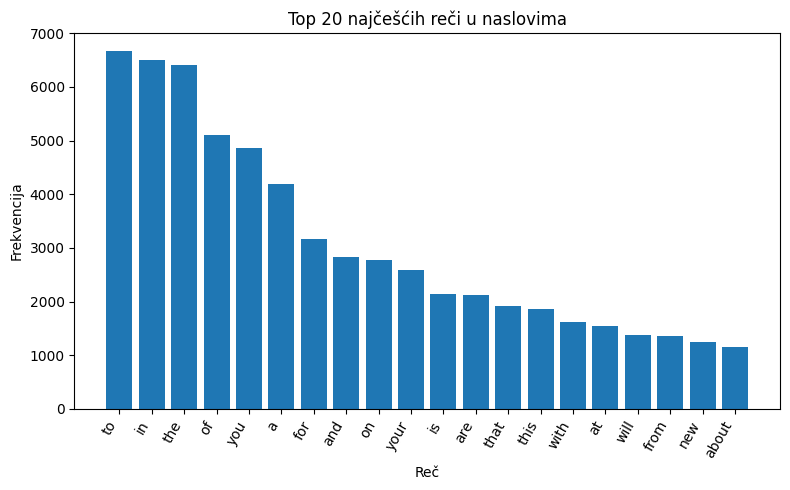

In [69]:
plt.figure(figsize=(8,5))
plt.bar(top_df["word"], top_df["freq"])
plt.title("Top 20 najčešćih reči u naslovima")
plt.xlabel("Reč")
plt.ylabel("Frekvencija")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Najčešće reči u korpusu su pretežno funkcionalne reči (npr. *to, in, the, of, and*), 
što je očekivano u engleskom jeziku.

Međutim, zanimljivo je prisustvo reči kao što su *you* i *your*, 
koje se često povezuju sa clickbait stilom (direktno obraćanje čitaocu).

Ova analiza ukazuje da *potpuno automatsko uklanjanje stop-reči možda nije optimalna strategija*,
jer neke od čestih funkcionalnih reči mogu nositi signal relevantan za detekciju clickbait sadržaja.

In [70]:
freqs = np.array(list(cnt.values()))

hapax_count = np.sum(freqs == 1)
hapax_share_vocab = hapax_count / len(freqs)

print("Broj hapax reči (freq=1):", hapax_count)
print("Udeo hapax reči u vokabularu:", hapax_share_vocab)

# koliko reči se pojavljuje manje od 2/3/5 puta
for k in [2, 3, 5]:
    share = np.mean(freqs < k)
    print(f"Udeo reči sa frekvencijom < {k}: {share:.3f}")

Broj hapax reči (freq=1): 10745
Udeo hapax reči u vokabularu: 0.4547763152325729
Udeo reči sa frekvencijom < 2: 0.455
Udeo reči sa frekvencijom < 3: 0.603
Udeo reči sa frekvencijom < 5: 0.730


Analiza frekvencija pokazuje sledeće:

- Broj hapax reči (reči koje se pojavljuju samo jednom) iznosi **10,745**, 
  što predstavlja približno **45.5% ukupnog vokabulara**.
- Čak **60.3% reči** pojavljuje se manje od 3 puta,
- dok se **73.0% reči** pojavljuje manje od 5 puta.

Ovi rezultati ukazuju na veoma visok udeo retkih tokena u korpusu.

Veliki procenat retkih reči može dovesti do:
- povećane dimenzionalnosti TF-IDF matrice,
- veće sparsity reprezentacije,
- smanjene generalizacije modela.

Zbog toga postoji jasna motivacija za eksperimentalno testiranje parametra `min_df`,kojim se uklanjaju tokeni koji se pojavljuju u premalom broju dokumenata.

In [71]:
# Najčešće reči u clickbait naslovima
top_cb = (
    df[df["clickbait"] == 1]["headline"]
    .str.split(expand=True)
    .stack()
    .value_counts()
    .reset_index()
)

top_cb.columns = ["word", "freq_clickbait"]


# Najčešće reči u non-clickbait naslovima
top_non = (
    df[df["clickbait"] == 0]["headline"]
    .str.split(expand=True)
    .stack()
    .value_counts()
    .reset_index()
)

top_non.columns = ["word", "freq_non_clickbait"]

In [72]:
# Spajanje tabela po reči (clickbait vs non-clickbait)

top_compare = pd.merge(
    top_cb,
    top_non,
    on="word",
    how="outer"
).fillna(0)

# pretvori frekvencije u int (da ne budu float zbog fillna)
top_compare["freq_clickbait"] = top_compare["freq_clickbait"].astype(int) #koliko puta se rec pojavljuje u clickbait naslovima
top_compare["freq_non_clickbait"] = top_compare["freq_non_clickbait"].astype(int) #koliko se puta pojavljuje u nonclikbait

# razlika frekvencija
top_compare["diff_clickbait_minus_non"] = ( 
    top_compare["freq_clickbait"] - top_compare["freq_non_clickbait"]
)

#apsolutna razlika
top_compare["abs_diff"] = top_compare["diff_clickbait_minus_non"].abs()

top_compare = top_compare.sort_values("abs_diff", ascending=False)

# prikaz top 20 najrazličitijih reči
top_compare.head(20)

,word,freq_clickbait,freq_non_clickbait,diff_clickbait_minus_non,abs_diff
27067,You,4805,19,4786,4786
24477,The,4723,171,4552,4552
31014,in,6,4354,-4348,4348
34946,to,7,3394,-3387,3387
24735,To,3231,23,3208,3208
32272,of,12,2662,-2650,2650
27088,Your,2536,37,2499,2499
17774,Of,2422,4,2418,2418
2542,A,2600,234,2366,2366
3619,Are,1938,127,1811,1811


Poređenjem najčešćih reči u clickbait i non-clickbait naslovima mogu se uočiti jasne stilističke razlike.

Kod clickbait naslova među najfrekventnijim rečima pojavljuju se:
- *you*
- *your*
- *this*
- *that*
- *will*

Ove reči ukazuju na direktno obraćanje čitaocu i naglašavanje budućih ili emocionalnih događaja,
što je tipična karakteristika clickbait stila.

Sa druge strane, non-clickbait naslovi češće sadrže reči kao što su:
- *in*
- *at*
- *new*
- *after*
- *with*

Ove reči su karakteristične za informativne i neutralne novinarske konstrukcije.

Ova razlika potvrđuje da clickbait i non-clickbait naslovi koriste različite jezičke obrasce, što sugeriše da model može naučiti razlike ne samo na osnovu dužine,
već i na osnovu leksičkih karakteristika teksta.

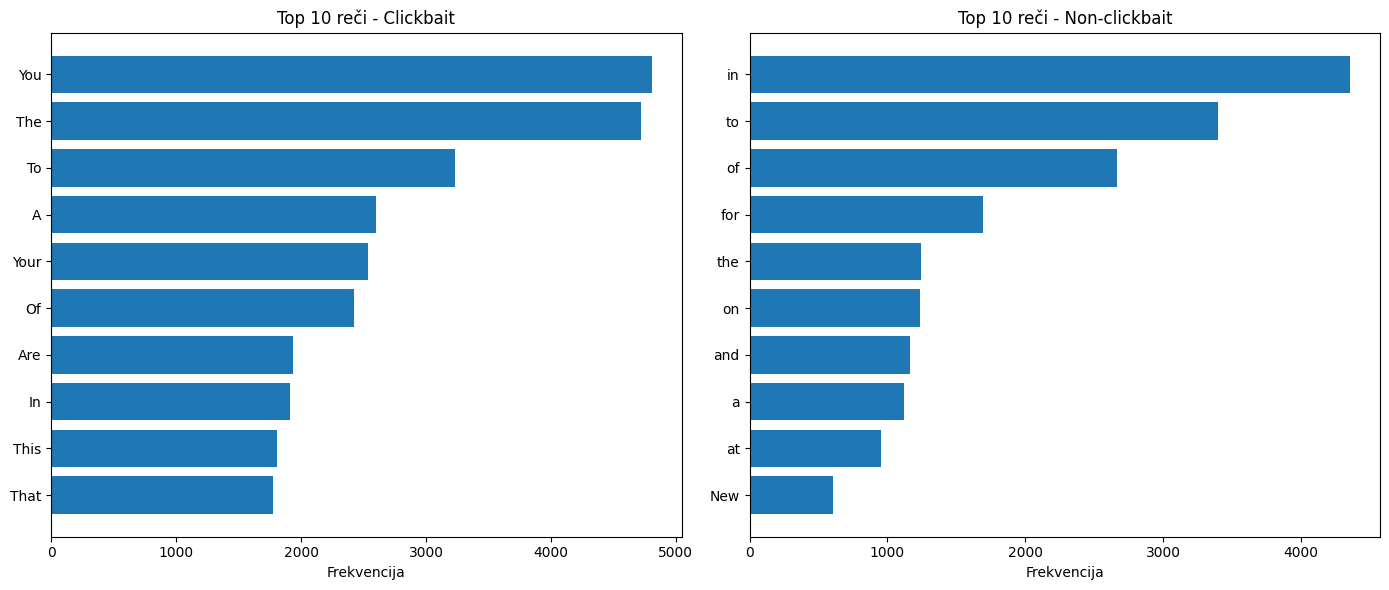

In [73]:
import matplotlib.pyplot as plt

# uzimamo top 10 po klasama
top_cb_10 = top_cb.head(10)
top_non_10 = top_non.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clickbait graf
axes[0].barh(top_cb_10["word"], top_cb_10["freq_clickbait"])
axes[0].invert_yaxis()
axes[0].set_title("Top 10 reči - Clickbait")
axes[0].set_xlabel("Frekvencija")

# Non-clickbait graf
axes[1].barh(top_non_10["word"], top_non_10["freq_non_clickbait"])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 reči - Non-clickbait")
axes[1].set_xlabel("Frekvencija")

plt.tight_layout()
plt.show()

Vizuelna ilustracija leksičkih razlika između klasa

### 2.2.1 WordCloud analiza

WordCloud predstavlja vizuelnu tehniku za prikaz najčešćih reči u tekstualnom korpusu. 
Veličina svake reči proporcionalna je njenoj učestalosti u skupu podataka. 
Na ovaj način možemo intuitivno uočiti koje reči dominiraju u clickbait i non-clickbait naslovima.

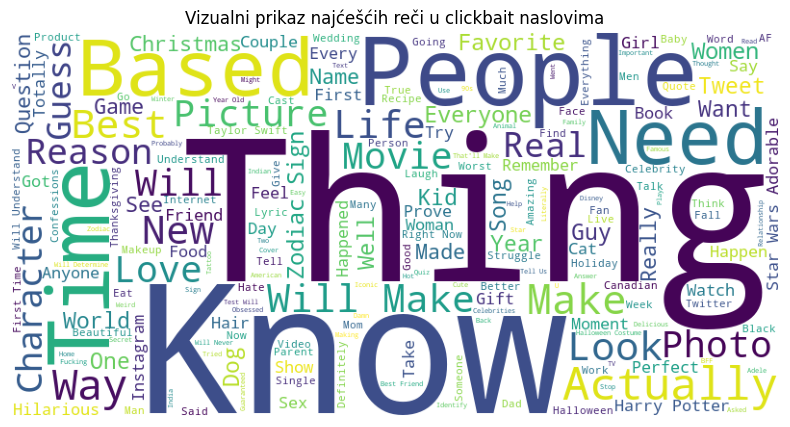

In [74]:
from wordcloud import WordCloud
clickbait_text = " ".join(df[df["clickbait"] == 1]["headline"])

wordcloud_clickbait = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(clickbait_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_clickbait)
plt.axis("off")
plt.title("Vizualni prikaz najćešćih reči u clickbait naslovima")

plt.show()

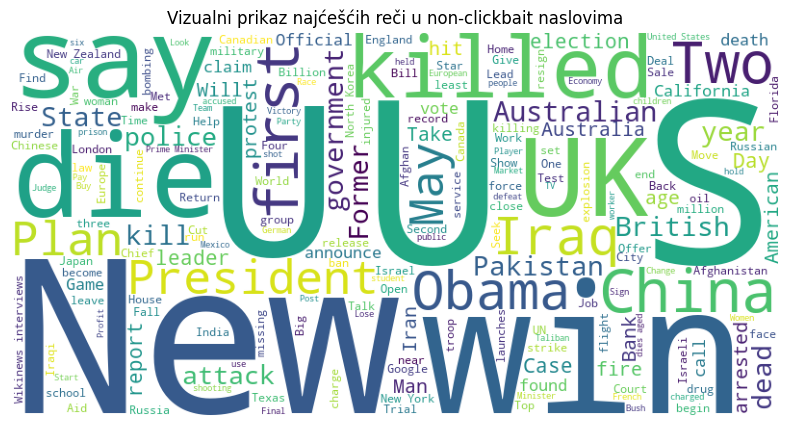

In [75]:
non_clickbait_text = " ".join(df[df["clickbait"] == 0]["headline"])

wordcloud_non = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(non_clickbait_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_non)
plt.axis("off")
plt.title("Vizualni prikaz najćešćih reči u non-clickbait naslovima")

plt.show()

Vizuelna analiza pokazuje razlike u vokabularu između clickbait i standardnih naslova. 
Clickbait naslovi češće sadrže emocionalno obojene ili senzacionalističke izraze, dok su 
non-clickbait naslovi informativniji i neutralniji.

## 2.3 Stil i signal

U ovom podpoglavlju posmatramo koliko naslova sadrži znakove interpunkcije, brojeve, reči napisane velikim slovima.

1. Ukupna zastupljenost stilskih indikatora:


In [76]:
# indikator za !
df["has_exclamation"] = df["headline"].str.contains("!", regex=False)

# indikator za ?
df["has_question"] = df["headline"].str.contains("?", regex=False)

# indikator za broj
df["has_number"] = df["headline"].str.contains(r"\d", regex=True)

# indikator za ALL CAPS reči (min 3 slova)
df["has_allcaps"] = df["headline"].str.contains(r"\b[A-Z]{3,}\b", regex=True)

# indikator za dvostruke navodnike "
df["has_double_quotes"] = df["headline"].str.contains('"', regex=False)

# indikator za jednostruke navodnike '
df["has_single_quotes"] = df["headline"].str.contains("'", regex=False)

# indikator za okrugle zagrade ()
df["has_parentheses"] = df["headline"].str.contains(r"[()]", regex=True)

# prosečne vrednosti (učešće u datasetu)
df[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean()

has_exclamation      0.001187
has_question         0.005000
has_number           0.313688
has_allcaps          0.051687
has_double_quotes    0.077281
has_single_quotes    0.151812
has_parentheses      0.002812
dtype: float64

Analiza pokazuje:
- Uzvičnik (!) prisutan je u približno **0.12%** naslova.
- Upitnik (?) pojavljuje se u oko **0.5%** naslova.
- Brojevi su prisutni u čak **31.4%** naslova.
- ALL CAPS reči javljaju se u oko **5.2%** naslova.

Najzastupljeniji indikator su brojevi, što je u skladu sa tipičnim clickbait obrascem
(npr. “7 things…”, “10 reasons…”).

In [77]:
df.groupby("clickbait")[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean() * 100 #za procente

,has_exclamation,has_question,has_number,has_allcaps,has_double_quotes,has_single_quotes,has_parentheses
clickbait,,,,,,,
0,0.049997,0.731204,18.630086,6.787076,1.187426,7.168302,0.199988
1,0.187512,0.268767,44.109007,3.550222,14.269642,23.195200,0.362523


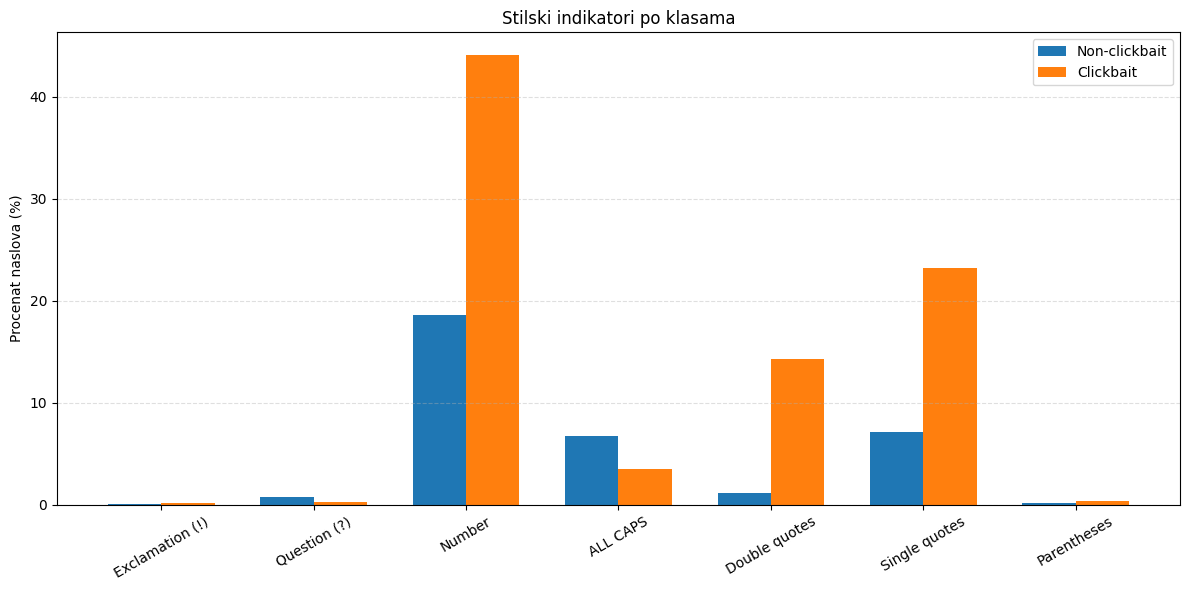

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# izračunavanje srednjih vrednosti
style_means = df.groupby("clickbait")[[
    "has_exclamation",
    "has_question",
    "has_number",
    "has_allcaps",
    "has_double_quotes",
    "has_single_quotes",
    "has_parentheses"
]].mean()

# u procente
style_means_percent = style_means * 100

# etikete (mora isti redosled kao kolone)
labels = [
    "Exclamation (!)",
    "Question (?)",
    "Number",
    "ALL CAPS",
    "Double quotes",
    "Single quotes",
    "Parentheses"
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width/2, style_means_percent.loc[0].values, width, label="Non-clickbait")
ax.bar(x + width/2, style_means_percent.loc[1].values, width, label="Clickbait")

ax.set_ylabel("Procenat naslova (%)")
ax.set_title("Stilski indikatori po klasama")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Poređenje stilskih indikatora po klasama otkriva jasne i konzistentne razlike između clickbait i non-clickbait naslova.

Najizraženija razlika uočena je kod upotrebe brojeva: oni su prisutni u približno 44.1% clickbait naslova, dok se u non-clickbait naslovima pojavljuju u svega 18.6% slučajeva. Ovaj rezultat potvrđuje da numeričke konstrukcije (tzv. listicle obrasci) predstavljaju dominantnu stilsku karakteristiku clickbait sadržaja.

Pored toga, značajna razlika uočena je i kod upotrebe navodnika. Double quotes se pojavljuju u oko 14.3% clickbait naslova, naspram samo 1.2% u non-clickbait klasi, dok su single quotes prisutni u oko 23.2% clickbait naslova u poređenju sa 7.2% u non-clickbait grupi. Ovi rezultati ukazuju da clickbait naslovi češće koriste narativni ili senzacionalistički stil izražavanja.

Sa druge strane, ALL CAPS reči su češće zastupljene u non-clickbait naslovima (6.8%) nego u clickbait naslovima (3.6%), što sugeriše da kapitalizacija nije dominantan clickbait signal u ovom skupu podataka. Upitnici, uzvičnici i zagrade pokazuju nisku učestalost u obe klase, te ne predstavljaju snažan diskriminativni faktor.

Ukupno posmatrano, stilistički obrasci sa najvećom diskriminativnom vrednošću u ovom korpusu su numeričke konstrukcije i upotreba navodnika, dok ostali analizirani indikatori imaju ograničen doprinos razlikovanju klasa.

## 2.4 Lexical Diversity (TTR)

U ovoj sekciji merimo leksičku raznovrsnost (TTR - Type-Token Ratio), ona predstavlja odnos između broja jedinstvenih reči i ukupnog broja tokena.

Ova metrika pruža uvid u raznovrsnost jezika, potencijalnu repetetivnost stilskih obrazaca, razlike u leksičkoj kompleksnosti između klasa.

In [79]:
def compute_ttr(texts):
    tokens = []
    for t in texts:
        tokens.extend(tokenize_for_eda(t))
    return len(set(tokens)) / len(tokens)

ttr_overall = compute_ttr(df["headline"])
ttr_cb = compute_ttr(df[df["clickbait"] == 1]["headline"])
ttr_non = compute_ttr(df[df["clickbait"] == 0]["headline"])

print("TTR (ukupno):", ttr_overall)
print("TTR (clickbait):", ttr_cb)
print("TTR (non-clickbait):", ttr_non)

TTR (ukupno): 0.08319424784681582
TTR (clickbait): 0.07787758731154958
TTR (non-clickbait): 0.1317384004884005


*Budući da su klase približno izjednačene po broju dokumenata, poređenje TTR vrednosti je metodološki opravdano.*

Ukupna vrednost TTR u korpusu iznosi približno **0.083**, što ukazuje na relativno nisku leksičku raznovrsnost, što je očekivano za kratke tekstualne forme poput naslova.

Međutim, razlika između klasa je izražena:

- Clickbait naslovi imaju nižu TTR vrednost (**0.078**), što sugeriše veću repetitivnost i upotrebu šablonskih fraza.
- Non-clickbait naslovi pokazuju značajno višu TTR vrednost (**0.131**), što ukazuje na raznovrsniji i informativniji vokabular.

Ovi rezultati potvrđuju hipotezu da clickbait stil karakteriše veća upotreba ponavljajućih obrazaca i ograničenog skupa reči, dok non-clickbait naslovi pokazuju veću leksičku raznovrsnost.

## 2.5 Analiza šuma u tekstualnom korpusu

Kvalitet tekstualnih podataka u velikoj meri zavisi od prisustva tehničkog šuma, koji može negativno uticati na proces tokenizacije, vektorizacije i performanse modela mašinskog učenja. 
U okviru ove analize izvršeba je detekcija sledećih potencijalnih izvora šumova:
- HTML tagovi
- Emoji simboliu (unicode opseg)
- Višestruki uzvičnici i upitnici
- Specijalni simboli koji odstupaju od staandardne alfanumeričke strukture

In [80]:
# 1. HTML tagovi
df["has_html"] = df["headline"].str.contains(r"<.*?>", regex=True)

# 2. Pravi emoji (Unicode opseg)
df["has_emoji"] = df["headline"].str.contains(
    r"[\U00010000-\U0010ffff]", 
    regex=True
)

# 3. Višestruki uzvičnici
df["multiple_exclamation"] = df["headline"].str.contains(r"!{2,}", regex=True)

# 4. Višestruki upitnici
df["multiple_question"] = df["headline"].str.contains(r"\?{2,}", regex=True)

# 5. Nealfanumerički simboli (bez standardne interpunkcije)
df["has_special_symbols"] = df["headline"].str.contains(
    r"[^a-zA-Z0-9\s\.\,\!\?\-\'\"]",
    regex=True
)

# Procenat pojavljivanja po klasama
noise_stats = df.groupby("clickbait")[[
    "has_html",
    "has_emoji",
    "multiple_exclamation",
    "multiple_question",
    "has_special_symbols"
]].mean() * 100

noise_stats

,has_html,has_emoji,multiple_exclamation,multiple_question,has_special_symbols
clickbait,,,,,
0,0.0,0.0,0.000000,0.0,9.430661
1,0.0,0.0,0.012501,0.0,3.843990


Analiza tehničkog šuma pokazuje da dataset ne sadrži HTML oznake niti emoji simbole, što ukazuje na visok inicijalni kvalitet podataka. Prisustvo višestrukih znakova interpunkcije je zanemarljivo, čak i kod clickbait naslova.

Interesantno je da non-clickbait naslovi imaju veći procenat specijalnih simbola (9.43%) u odnosu na clickbait naslove (3.84%). Ovo može biti posledica češće upotrebe crtica, zagrada ili tehničkih termina u informativnim naslovima, dok clickbait naslovi teže jednostavnijoj i direktnijoj formi izražavanja.

Ovi rezultati potvrđuju da dataset ne sadrži značajan tehnički šum koji bi degradirao performanse modela, te da eventualne razlike između klasa proizilaze iz stilističkih, a ne tehničkih karakteristika.

------------------------------

# 3. Modeliranje: Baseline model

Nakon analize kvaliteta i stilskih karakteristika teksta, prelazimo na fazu modeliranja. 
Cilj baseline modela je da se uspostavi referentna tacka performansi bez napredne preobrade teksta.

Baseline model koristi:
- TF-IDF reprezentaciju teksta
- Logistic Regression klasifikator
- Minimalnu obradu

Ovaj pristup omogućava proceni koliko sam model može da detektuje obrasce bez dodatnih poboljšsanja.

### Organizacija eksperimenata

Eksperimenti su organizovani tako da se postepeno uvode tehnike predobrade, kako bi se izolovao njihov pojedinačni i kombinovani uticaj na performanse modela.

Polazna tačka predstavlja baseline model sa minimalnom obradom teksta. Nakon toga, uvode se dodatne tehnike predobrade, pri čemu se nakon svakog koraka evaluiraju performanse modela koristeći iste metrike.

Na ovaj način primenjuje se *ablation pristup*, koji omogućava analizu doprinosa svake pojedinačne tehnike.

## 3.1 Podela podataka (stratified split)

Podatke delimo na trening i test skupu (80/20).
Koristimo *stratifikovanu* podelu kako bi distribucija klasa ostala proporcionalna u oba skupa -> time se obezbeđuje reprezentativna evaluacija modela

In [81]:
X = df["headline"]
y = df["clickbait"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Distribucija klasa u trening skupu:")
print(y_train.value_counts(normalize=True))

print("\nDistribucija klasa u test skupu:")
print(y_test.value_counts(normalize=True))

Distribucija klasa u trening skupu:
clickbait
0    0.500039
1    0.499961
Name: proportion, dtype: float64

Distribucija klasa u test skupu:
clickbait
1    0.5
0    0.5
Name: proportion, dtype: float64


## 3.2 Baseline model: TF-IDF + Logistic Regression

Baseline model koristi TF-IDF reprezentaciju bez:
- uklanjanja stop reči
- n-grama
- dodatne normalizacije
- filtriranja retkih ili čestih tokena

Na ovaj način dobijamo referentne performanse pre primene naprednih tehnika preobrade.

In [82]:
#baseline model
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True)),
    ("clf", LogisticRegression(max_iter=2000))
])
#treniramo trening skup
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

## 3.3 Evaluacija baseline modela

Model se evaluira na test skupu koristeći sledeće metrike:
- Accuracy (tacnost)
- Precision
- Recall
- F1-score

F1-score je posebno značajan kod binarne tekstualne klasifikacije jer balansira preciznost i odziv

In [83]:
report_dict = classification_report(
    y_test,
    y_pred_baseline,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df = report_df.loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]

report_df.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df = report_df.round(4)

styled_report = (
    report_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Baseline Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "22px"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("margin-bottom", "15px")]},
        {"selector": "th",
         "props": [("font-size", "18px"),
                   ("text-align", "center")]},
    ])
)

styled_report

,precision,recall,f1-score,support
Non-Clickbait,0.9581,0.9781,0.9680,3200
Clickbait,0.9777,0.9572,0.9673,3200
Accuracy,0.9677,0.9677,0.9677,1
Macro Avg,0.9679,0.9677,0.9677,6400
Weighted Avg,0.9679,0.9677,0.9677,6400


Baseline model ostvaruje ukupnu **tačnost (accuracy) od 96.77%**, što ukazuje na veoma visoke početne performanse u zadatku detekcije clickbait naslova.

S obzirom na to da je skup podataka balansiran (3200 primera po klasi), accuracy predstavlja pouzdanu metriku i nije rezultat neravnoteže klasa.

**Klasa: Non-Clickbait**

- **Precision:** 0.9581  
- **Recall:** 0.9781  
- **F1-score:** 0.9680  

Model pokazuje izuzetno dobre performanse u prepoznavanju non-clickbait naslova.  
Visoka vrednost recall (97.81%) znači da model retko propušta stvarne non-clickbait primere.

Precision od 95.81% ukazuje da mali procenat clickbait naslova biva pogrešno klasifikovan kao non-clickbait.

Ovi rezultati potvrđuju da model vrlo uspešno identifikuje neutralne i informativne naslove.

**Klasa: Clickbait**

- **Precision:** 0.9777  
- **Recall:** 0.9572  
- **F1-score:** 0.9673  

Model je veoma precizan prilikom predviđanja clickbait sadržaja (97.77%), što znači da su predikcije ove klase u velikoj meri tačne.

Međutim, nešto niža vrednost recall (95.72%) pokazuje da model propušta određeni broj clickbait primera.

To ukazuje na to da baseline model može imati poteškoća u prepoznavanju suptilnijih ili semantički kompleksnijih clickbait obrazaca.


**Uravnoteženost modela**

Vrednosti **Macro Average F1-score (0.9677)** i **Weighted Average F1-score (0.9677)** su gotovo identične, što potvrđuje da model ne favorizuje nijednu klasu i da su performanse ravnomerno raspoređene.

**Zaključak**

Rezultati pokazuju da baseline model ostvaruje veoma visoke i stabilne performanse.  
Iako su metrike već na visokom nivou, dalja unapređenja mogu biti usmerena na povećanje recall vrednosti za clickbait klasu kako bi se smanjio broj propuštenih primera.

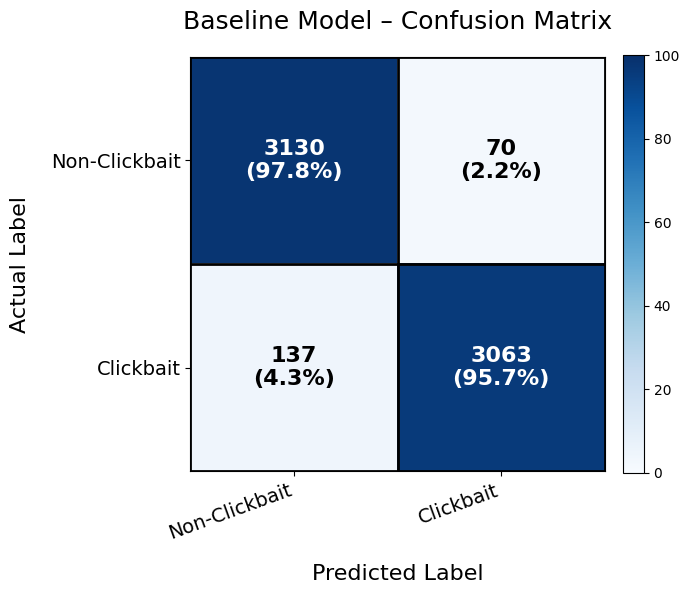

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Kreiramo matricu
cm = confusion_matrix(y_test, y_pred_baseline)

# Računamo procente po redu
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(7, 7))

# JAČI colormap
im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)

# Obeležavanje osa
classes = ["Non-Clickbait", "Clickbait"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=14)
ax.set_yticklabels(classes, fontsize=14)

ax.set_xlabel("Predicted Label", fontsize=16, labelpad=15)
ax.set_ylabel("Actual Label", fontsize=16, labelpad=15)

# Rotacija x labela
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# Upis vrednosti unutar kvadrata
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm_percent[i, j] > 50 else "black"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color=text_color,
            fontsize=16,
            fontweight="bold"
        )

# Pravimo kvadrate savršeno jednake
ax.set_aspect("equal")

# Grid linije da izgleda kao prava matrica
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Naslov
plt.title("Baseline Model – Confusion Matrix", fontsize=18, pad=20)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

 ## 3.4 Interpretacija modela – najvažnije reči

Koeficijenti logističke regresije omogućavaju interpretaciju modela. 
Pozitivni koeficijenti ukazuju na reči koje su karakteristične za clickbait naslove, 
dok negativni koeficijenti ukazuju na reči tipične za non-clickbait naslove.

Analiza ovih reči omogućava uvid u lingvističke obrasce koje model koristi za klasifikaciju.

In [85]:
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

In [86]:
top_clickbait = np.argsort(coefficients)[-20:]

print("Top words indicating CLICKBAIT:\n")

for i in reversed(top_clickbait):
    print(feature_names[i], coefficients[i])

Top words indicating CLICKBAIT:

you 12.519105422938566
this 9.042072776233189
your 8.349354713340826
the 6.322480147977565
that 5.981446273298825
these 5.925133082276824
people 5.423319803857711
17 5.413816280275033
are 5.273995416524507
what 5.266297897986185
2015 5.206715272013069
things 5.136277648590377
how 5.134157505323017
here 5.068652126727773
21 5.010845550206033
we 4.972469925260536
who 4.957898158872104
her 4.8648238148236
19 4.493548120819098
everyone 4.352671521948558


In [87]:
top_non = np.argsort(coefficients)[:20]

print("Top words indicating NON-CLICKBAIT:\n")

for i in top_non:
    print(feature_names[i], coefficients[i])

Top words indicating NON-CLICKBAIT:

in -4.131920937794967
obama -3.3651194802812943
wins -3.2321548081548555
dies -3.160361421989014
uk -3.1188185810000877
says -3.0428466414714737
australian -2.7199831821510614
china -2.462884508075658
kills -2.3963643810923925
may -2.3112053239198995
court -2.3041260835004005
killed -2.2693210863406867
mets -2.2477511008221023
police -2.241382691908118
iraq -2.233696345297738
wikinews -2.1788269661913153
at -2.1570166912244697
president -2.1317724172387096
knicks -2.0562585558436313
dead -2.014817948607436


Zaključak interpretacije

Rezultati analize pokazuju da model uspešno prepoznaje lingvističke obrasce karakteristične za clickbait sadržaj. Clickbait naslovi često koriste personalizovan i emocionalno obojen jezik, dok non-clickbait naslovi sadrže više informativnih i konkretnih termina. 

Ova interpretacija potvrđuje da model donosi odluke na osnovu relevantnih jezičkih karakteristika teksta, što dodatno doprinosi njegovoj interpretabilnosti i pouzdanosti.

Važno je napomenuti da se ova analiza razlikuje od prethodne eksploratorne analize podataka (EDA). 
U ranijoj fazi analizirane su najčešće reči u datasetu na osnovu frekvencije pojavljivanja. 
U ovoj fazi analiziraju se koeficijenti modela logističke regresije, koji predstavljaju stvarni 
doprinos pojedinačnih reči u procesu klasifikacije. 

Zbog toga su u ovoj analizi identifikovane reči koje model smatra najinformativnijim za razlikovanje 
clickbait i non-clickbait naslova, a ne nužno reči koje se najčešće pojavljuju u datasetu.

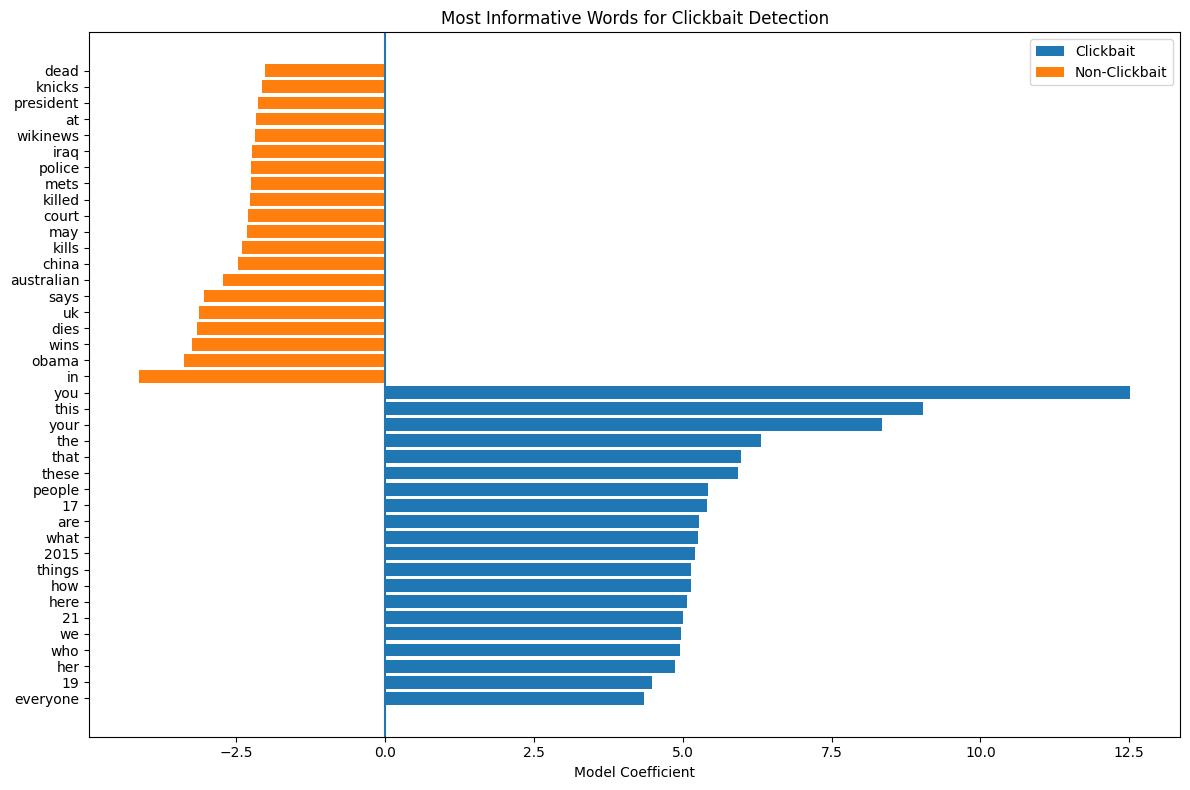

In [88]:
# uzimamo komponente pipeline-a
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

# feature names i koeficijenti
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# top clickbait (pozitivni koeficijenti)
top_cb_idx = np.argsort(coefficients)[-20:]
top_cb_words = feature_names[top_cb_idx]
top_cb_scores = coefficients[top_cb_idx]

# top non-clickbait (negativni koeficijenti)
top_non_idx = np.argsort(coefficients)[:20]
top_non_words = feature_names[top_non_idx]
top_non_scores = coefficients[top_non_idx]

# DataFrame za lakše crtanje
cb_df = pd.DataFrame({
    "word": top_cb_words,
    "score": top_cb_scores
}).sort_values("score")

non_df = pd.DataFrame({
    "word": top_non_words,
    "score": top_non_scores
}).sort_values("score")

# vizualizacija
plt.figure(figsize=(12,8))

plt.barh(cb_df["word"], cb_df["score"], label="Clickbait")
plt.barh(non_df["word"], non_df["score"], label="Non-Clickbait")

plt.axvline(0)
plt.xlabel("Model Coefficient")
plt.title("Most Informative Words for Clickbait Detection")

plt.legend()

plt.tight_layout()
plt.show()

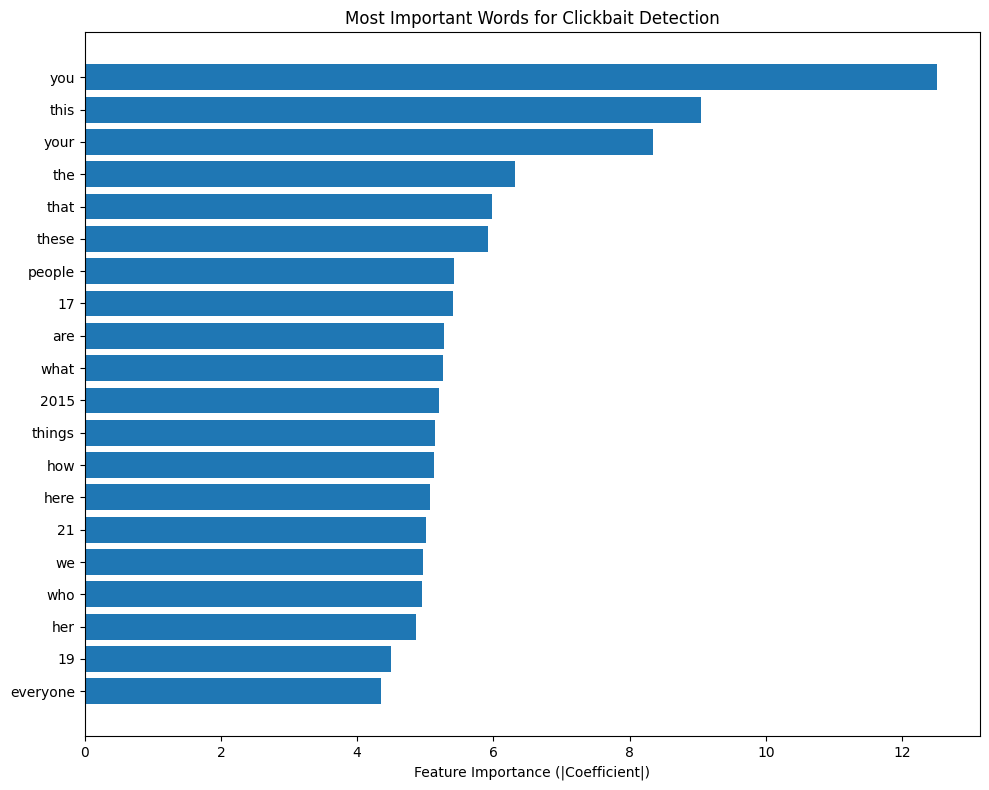

In [89]:
# uzimamo komponente modela
vectorizer = baseline_model.named_steps["tfidf"]
model = baseline_model.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# importance = apsolutna vrednost koeficijenta
importance = np.abs(coefficients)

# top 20 najvažnijih reči
top_idx = np.argsort(importance)[-20:]

top_words = feature_names[top_idx]
top_scores = importance[top_idx]

importance_df = pd.DataFrame({
    "word": top_words,
    "importance": top_scores
}).sort_values("importance")

plt.figure(figsize=(10,8))

plt.barh(importance_df["word"], importance_df["importance"])

plt.xlabel("Feature Importance (|Coefficient|)")
plt.title("Most Important Words for Clickbait Detection")

plt.tight_layout()
plt.show()

Pored analize pozitivnih i negativnih koeficijenata, moguće je analizirati i apsolutne vrednosti koeficijenata kako bi se identifikovale najvažnije karakteristike modela. Apsolutna vrednost koeficijenta pokazuje koliki uticaj određena reč ima na odluku modela, bez obzira na klasu kojoj doprinosi.

Rezultati pokazuju da model najviše koristi reči koje su karakteristične za clickbait stil pisanja, kao i termine koji su tipični za informativne naslove. Ovakva analiza omogućava dodatno razumevanje ponašanja modela i potvrđuje da model koristi relevantne lingvističke obrasce za klasifikaciju naslova.

##  3.5 ROC kriva i AUC

In [90]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = baseline_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

auc = roc_auc_score(y_test, y_pred_prob)

print("AUC score:", auc)

AUC score: 0.9949748046875


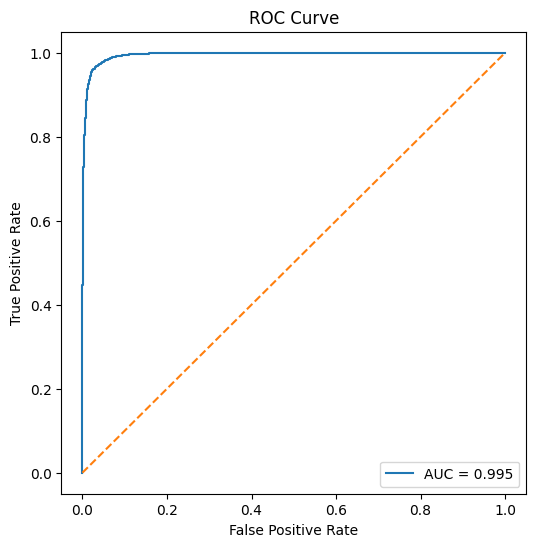

In [91]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

ROC kriva prikazuje odnos između **False Positive Rate (FPR)** i **True Positive Rate (TPR)** za različite vrednosti klasifikacionog praga. Na grafiku se vidi da kriva vrlo brzo raste ka gornjem levom uglu, što znači da model postiže **visoku stopu tačno pozitivnih klasifikacija uz veoma mali broj lažno pozitivnih grešaka**.

Već pri veoma malim vrednostima **FPR** model ostvaruje **TPR blizak 1**, što ukazuje da model uspešno prepoznaje većinu clickbait naslova bez značajnog pogrešnog označavanja ne-clickbait naslova kao clickbait.

Isprekidana dijagonalna linija predstavlja performanse **nasumičnog klasifikatora**. Pošto se ROC kriva modela nalazi značajno iznad te linije, jasno je da model ima **visoku diskriminativnu sposobnost** između dve klase.

Vrednost **AUC (Area Under Curve)** iznosi približno **0.995**, što ukazuje na **izuzetno visok kvalitet modela**. Ova vrednost znači da postoji oko **99.5% verovatnoće da će model dodeliti veću verovatnoću clickbait klasi stvarnom clickbait naslovu nego ne-clickbait naslovu**.

Na osnovu ROC krive i AUC metrike može se zaključiti da bazni model veoma uspešno razlikuje clickbait i ne-clickbait naslove i postiže **veoma visoke performanse klasifikacije**.

## Sledeći koraci eksperimenata

Nakon detaljne analize baseline modela, koji je postigao visoke i stabilne performanse, prelazi se na sledeću fazu eksperimentisanja sa ciljem daljeg unapređenja modela.

Baseline model predstavlja referentnu tačku u ovom istraživanju, jer omogućava jasnu procenu koliko model može da nauči iz podataka uz minimalnu obradu. Dobijeni rezultati ukazuju da već i osnovna TF-IDF reprezentacija u kombinaciji sa logističkom regresijom daje veoma dobre performanse u zadatku klasifikacije clickbait naslova.

Uprkos tome, cilj ovog rada nije samo postizanje visokih performansi, već i razumevanje uticaja pojedinačnih tehnika predobrade na kvalitet modela. Zbog toga se u nastavku uvode dodatne tehnike predobrade, pri čemu se svaka od njih posmatra izolovano, ali i u kombinaciji sa drugim tehnikama.

Eksperimenti su organizovani tako da se postepeno uvode sledeće metode:

- uklanjanje stop-reči  
- primena stemming-a  
- primena lematizacije  
- proširenje reprezentacije korišćenjem n-grama  

Za svaki od navedenih koraka trenira se model sa identičnim podešavanjima kao u baseline pristupu, čime se obezbeđuje fer poređenje rezultata. Na taj način moguće je jasno sagledati doprinos svake tehnike, kao i identifikovati kombinaciju koja daje najbolje performanse.

Ovakav pristup predstavlja tzv. *ablation analizu*, gde se sistematski ispituje kako dodavanje ili uklanjanje pojedinačnih komponenti utiče na ukupni kvalitet modela.

Na kraju eksperimentalnog dela, rezultati svih modela biće objedinjeni i upoređeni kroz zajedničku tabelu, kako bi se identifikovao optimalan pristup za ovaj zadatak.

## 3.6 Eksperiment sa min_df

U prethodnom koraku korišćena je standardna TF-IDF reprezentacija koja uključuje sve reči iz korpusa, bez obzira na njihovu učestalost.

Međutim, u realnim tekstualnim podacima često postoje reči koje se pojavljuju veoma retko (npr. tipografske greške, specifična imena ili jedinstveni izrazi). Ovakve reči mogu predstavljati šum i dovesti do povećanja dimenzionalnosti prostora bez značajnog doprinosa modelu.

Zbog toga se uvodi parametar *min_df*, koji omogućava filtriranje reči koje se pojavljuju u malom broju dokumenata.

U ovom eksperimentu testirana je vrednost:

- **min_df = 5**

što znači da se zadržavaju samo reči koje se pojavljuju u najmanje 5 dokumenata u trening skupu.

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# =========================
# 1. TF-IDF sa min_df
# =========================
vectorizer_min_df = TfidfVectorizer(min_df=5)

X_train_min_df = vectorizer_min_df.fit_transform(X_train)
X_test_min_df = vectorizer_min_df.transform(X_test)

# =========================
# 2. Treniranje modela
# =========================
model_min_df = LogisticRegression(max_iter=1000)
model_min_df.fit(X_train_min_df, y_train)

# =========================
# 3. Predikcija
# =========================
y_pred_min_df = model_min_df.predict(X_test_min_df)

# =========================
# 4. Classification report
# =========================
report_dict = classification_report(
    y_test,
    y_pred_min_df,
    output_dict=True
)

report_df_min_df = pd.DataFrame(report_dict).transpose()

# uzimamo samo relevantne redove
report_df_min_df = report_df_min_df.loc[
    ["0", "1", "accuracy", "macro avg", "weighted avg"]
]

# preimenovanje
report_df_min_df.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

# =========================
# 5. FIX za accuracy red
# =========================
accuracy_value = report_dict["accuracy"]

report_df_min_df.loc["Accuracy", "precision"] = ""
report_df_min_df.loc["Accuracy", "recall"] = ""
report_df_min_df.loc["Accuracy", "f1-score"] = round(accuracy_value, 4)
report_df_min_df.loc["Accuracy", "support"] = len(y_test)

# konverzija numeričkih kolona
for col in ["precision", "recall", "f1-score", "support"]:
    report_df_min_df[col] = pd.to_numeric(report_df_min_df[col], errors="coerce")

# zaokruživanje
report_df_min_df[["precision", "recall", "f1-score"]] = report_df_min_df[
    ["precision", "recall", "f1-score"]
].round(4)

# =========================
# 6. Styling
# =========================
styled_min_df = (
    report_df_min_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    }, na_rep="")
    .set_caption("Min_df Model – Classification Report")
    .set_properties(**{
        "font-size": "14px",
        "text-align": "center",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "22px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "16px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

styled_min_df

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5580\831084100.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  report_df_min_df.loc["Accuracy", "precision"] = ""
C:\Users\Administrator\AppData\Local\Temp\ipykernel_5580\831084100.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  report_df_min_df.loc["Accuracy", "recall"] = ""


,precision,recall,f1-score,support
Non-Clickbait,0.9574,0.9753,0.9663,3200
Clickbait,0.9748,0.9566,0.9656,3200
Accuracy,,,0.9659,6400
Macro Avg,0.9661,0.9659,0.9659,6400
Weighted Avg,0.9661,0.9659,0.9659,6400


### Analiza rezultata

U poređenju sa baseline modelom, koji ostvaruje tačnost od 0.9677, model sa parametrom *min_df = 5* postiže tačnost od 0.9659, što predstavlja blago smanjenje performansi.

Ovaj rezultat ukazuje da uklanjanje retkih reči nije dovelo do poboljšanja modela, već naprotiv, do gubitka određenih informacija koje su bile korisne za klasifikaciju.

Detaljnija analiza po klasama pokazuje da model i dalje zadržava balansirane performanse, ali dolazi do blagog pada recall vrednosti za clickbait klasu, što znači da model propušta nešto veći broj clickbait primera nego u baseline pristupu.

Moguće objašnjenje je da retke reči u ovom dataset-u nose specifične obrasce karakteristične za clickbait naslove (npr. neobične formulacije ili jedinstveni izrazi), te njihovo uklanjanje smanjuje sposobnost modela da prepozna takve obrasce.

Takođe, s obzirom na to da dataset nije izrazito šumovit, eliminacija retkih termina ne donosi značajnu korist u smislu redukcije šuma, već više utiče na smanjenje informativnosti reprezentacije.

### Zaključak

Rezultati ovog eksperimenta pokazuju da primena parametra *min_df* u ovom slučaju ne doprinosi poboljšanju performansi modela.

Iako teorijski uklanjanje retkih reči može smanjiti šum i poboljšati generalizaciju, u ovom dataset-u retki termini imaju značajnu diskriminativnu vrednost.

Zbog toga se zaključuje da je za ovaj zadatak zadržavanje celokupnog vokabulara, bez filtriranja pomoću parametra *min_df*, optimalniji pristup.

## 3.7 Eksperiment sa N-gramima

U prethodnim eksperimentima korišćena je unigramska reprezentacija, gde se tekst posmatra kao skup pojedinačnih reči.

Međutim, u tekstualnim podacima često značaj imaju i kombinacije reči, odnosno fraze. Clickbait naslovi često sadrže karakteristične izraze kao što su „you won’t believe“, „what happens next“, „this is what“, koji se ne mogu u potpunosti prepoznati analizom pojedinačnih reči.

Zbog toga se uvodi *N-gram* pristup, gde model uzima u obzir sekvence od više reči. U ovom eksperimentu testiran je:

- **bigram model (ngram_range = (1,2))**

što znači da model koristi i pojedinačne reči i parove uzastopnih reči.

In [93]:
bigram_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])

In [94]:
bigram_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [95]:
y_pred_bigram = bigram_model.predict(X_test)

In [96]:
from sklearn.metrics import classification_report


report_bigram = classification_report(y_test, y_pred_bigram, output_dict=True)
report_df_bigram = pd.DataFrame(report_bigram).transpose()


styled_report_bigram = (
    report_df_bigram.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Bigram Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "22px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "15px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "18px"),
                ("text-align", "center")
            ]
        }
    ])
)

styled_report_bigram

,precision,recall,f1-score,support
0,0.9632,0.9641,0.9636,3200
1,0.9640,0.9631,0.9636,3200
accuracy,0.9636,0.9636,0.9636,1
macro avg,0.9636,0.9636,0.9636,6400
weighted avg,0.9636,0.9636,0.9636,6400


#### Rezultati modela

Model sa bigram reprezentacijom postiže:

- Accuracy: **0.9636**
- F1-score: **0.9636**

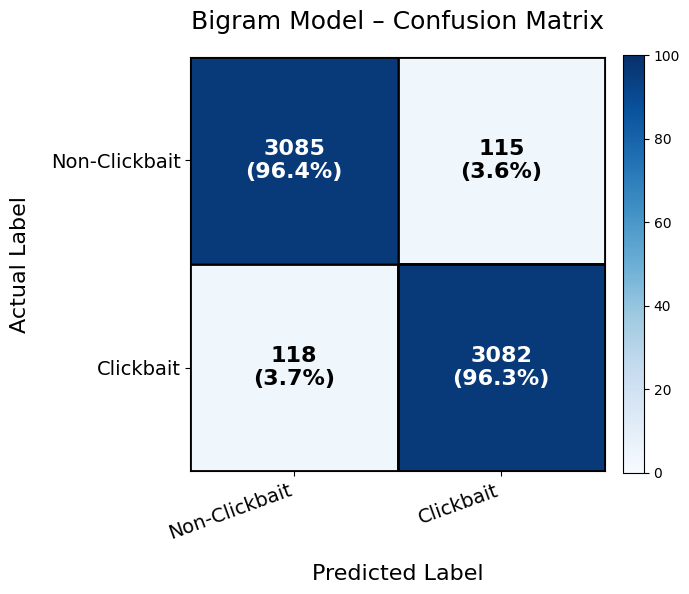

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Kreiramo matricu
cm = confusion_matrix(y_test, y_pred_bigram)

# Računamo procente po redu
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(7, 7))

# JAČI colormap
im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)

# Obeležavanje osa
classes = ["Non-Clickbait", "Clickbait"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=14)
ax.set_yticklabels(classes, fontsize=14)

ax.set_xlabel("Predicted Label", fontsize=16, labelpad=15)
ax.set_ylabel("Actual Label", fontsize=16, labelpad=15)

# Rotacija x labela
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# Upis vrednosti unutar kvadrata
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm_percent[i, j] > 50 else "black"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color=text_color,
            fontsize=16,
            fontweight="bold"
        )

# Kvadrati jednake veličine
ax.set_aspect("equal")

# Grid linije
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Naslov
plt.title("Bigram Model – Confusion Matrix", fontsize=18, pad=20)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Analiza rezultata

U poređenju sa baseline modelom, koji ostvaruje tačnost od 0.9677, bigram model postiže tačnost od 0.9636, što predstavlja blago pogoršanje performansi.

Iako uvođenje bigrama omogućava modelu da prepozna karakteristične fraze, rezultati pokazuju da ovo poboljšanje u reprezentaciji ne dovodi do bolje generalizacije na test skupu.

Jedan od razloga može biti značajno povećanje dimenzionalnosti prostora, jer broj mogućih kombinacija reči raste eksponencijalno. Ovo može dovesti do razređenosti podataka i otežati učenje stabilnih obrazaca.

Takođe, s obzirom na to da dataset već sadrži dovoljno informativne pojedinačne reči, dodatne informacije koje donose bigrami nisu dovoljno značajne da bi unapredile performanse modela.

### Zaključak

Rezultati ovog eksperimenta pokazuju da uvođenje bigram reprezentacije ne doprinosi poboljšanju performansi modela.

Iako teorijski omogućava bolje hvatanje konteksta kroz fraze, u ovom slučaju povećanje kompleksnosti modela ne rezultuje boljim performansama.

Zbog toga se zaključuje da je unigramska TF-IDF reprezentacija dovoljna za rešavanje ovog zadatka, jer već uspešno hvata ključne obrasce u tekstu.

# 4. Uticaj napredne predobrade na performanse modela

Nakon eksperimenata sa parametrima TF-IDF reprezentacije, u sledećem koraku ispituje se uticaj naprednijih tehnika jezičke predobrade na performanse klasifikacionog modela.

Fokus je stavljen na dve često korišćene tehnike: stemming i lematizaciju. Obe metode imaju cilj redukciju različitih morfoloških oblika reči na zajedničku osnovu, ali se razlikuju po načinu na koji to postižu i po količini semantičke informacije koju zadržavaju.

Cilj ove faze eksperimenata jeste da se proveri da li dodatna morfološka normalizacija doprinosi boljoj klasifikaciji clickbait naslova, ili u ovom slučaju dovodi do gubitka informacija koje su značajne za razlikovanje klasa.

## 4.1 Stemming

U ovom eksperimentu primenjuje se stemming kao tehnika predobrade teksta. Stemming svodi reči na njihov korenski oblik uklanjanjem nastavaka, pri čemu se ne vodi računa o tome da li dobijeni oblik predstavlja gramatički ispravnu reč.

Osnovna ideja ove metode jeste smanjenje dimenzionalnosti vokabulara i grupisanje srodnih oblika iste reči u jedinstvenu reprezentaciju. Na taj način model potencijalno može lakše da uči opštije obrasce, bez razlikovanja gramatičkih varijanti istog termina.

U teoriji, stemming može poboljšati generalizaciju modela, posebno u zadacima gde različiti oblici iste reči nose slično značenje. Međutim, kod kratkih tekstova kao što su naslovi, ovakva redukcija može biti previše agresivna i dovesti do gubitka važnih semantičkih nijansi.

In [98]:
print(df.columns.tolist())

['headline', 'clickbait', 'char_length', 'token_length', 'has_exclamation', 'has_question', 'has_number', 'has_allcaps', 'has_double_quotes', 'has_single_quotes', 'has_parentheses', 'has_html', 'has_emoji', 'multiple_exclamation', 'multiple_question', 'has_special_symbols']


In [99]:
from nltk.stem import PorterStemmer

print("Kolone u datasetu:", df.columns.tolist())

text_col = "headline"   


stemmer = PorterStemmer()

def stem_text_for_model(text):
    tokens = tokenize_for_eda(text)
    return " ".join([stemmer.stem(t) for t in tokens])


df["headline_stemmed"] = df[text_col].apply(stem_text_for_model)


df[["headline_stemmed"]].head()

Kolone u datasetu: ['headline', 'clickbait', 'char_length', 'token_length', 'has_exclamation', 'has_question', 'has_number', 'has_allcaps', 'has_double_quotes', 'has_single_quotes', 'has_parentheses', 'has_html', 'has_emoji', 'multiple_exclamation', 'multiple_question', 'has_special_symbols']


,headline_stemmed
0,should i get bing
1,which tv femal friend group do you belong in
2,the new star war the forc awaken trailer is here to give you chill
3,thi vine of new york on celebr big brother is fuck perfect
4,a coupl did a stun photo shoot with their babi after learn she had an inoper brain tumor


In [100]:
X_stem = df["headline_stemmed"]

X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stem, df["clickbait"], 
    test_size=0.2, 
    random_state=42,
    stratify=df["clickbait"]
)

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

vectorizer_stem = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer_stem.fit_transform(X_train_stem)
X_test_vec = vectorizer_stem.transform(X_test_stem)

model_stem = LogisticRegression(max_iter=1000)
model_stem.fit(X_train_vec, y_train)

y_pred_stem = model_stem.predict(X_test_vec)

report_dict_stem = classification_report(
    y_test,
    y_pred_stem,
    output_dict=True
)

report_df_stem = pd.DataFrame(report_dict_stem).transpose()

report_df_stem = report_df_stem.loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]

report_df_stem.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df_stem = report_df_stem.round(4)

styled_report_stem = (
    report_df_stem.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Stemming Model – Classification Report")
    .set_properties(**{
        'font-size': '18px',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "22px"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("margin-bottom", "15px")]},
        {"selector": "th",
         "props": [("font-size", "18px"),
                   ("text-align", "center")]},
    ])
)

styled_report_stem

,precision,recall,f1-score,support
Non-Clickbait,0.9340,0.9594,0.9465,3200
Clickbait,0.9582,0.9322,0.9450,3200
Accuracy,0.9458,0.9458,0.9458,1
Macro Avg,0.9461,0.9458,0.9458,6400
Weighted Avg,0.9461,0.9458,0.9458,6400


#### Rezultati modela

| Klasa         | Precision | Recall | F1-score | Support |
|---------------|-----------|--------|----------|---------|
| Non-clickbait | 0.9340    | 0.9594 | 0.9465   | 3200    |
| Clickbait     | 0.9582    | 0.9322 | 0.9450   | 3200    |
| **Accuracy**  |           |        | **0.9458** | 6400  |
| **Macro Avg** | 0.9461    | 0.9458 | 0.9458   | 6400    |
| **Weighted Avg** | 0.9461 | 0.9458 | 0.9458   | 6400    |

#### Poređenje sa baseline modelom

| Model     | Accuracy | F1-score (Clickbait) | Macro F1 |
|-----------|----------|----------------------|----------|
| Baseline  | 0.9677   | 0.9673               | 0.9677   |
| Stemming  | 0.9458   | 0.9450               | 0.9458   |

### Analiza rezultata

U poređenju sa baseline modelom, stemming pristup dovodi do primetnog pada performansi. Tačnost opada sa 0.9677 na 0.9458, dok F1-score za clickbait klasu pada sa 0.9673 na 0.9450.

Najizraženija promena vidi se u recall vrednosti za clickbait klasu, koja iznosi 0.9322. To znači da model nakon stemming obrade propušta veći broj clickbait primera nego baseline model.

Ovakav rezultat ukazuje da agresivna redukcija reči na korenski oblik u ovom zadatku ne pomaže modelu, već narušava kvalitet reprezentacije. Kod kratkih tekstova, kao što su naslovi, svaka reč nosi relativno veliku informativnu vrednost, pa gubitak morfoloških i semantičkih nijansi može negativno uticati na klasifikaciju.

Dodatno, clickbait naslovi često koriste specifične formulacije, stilizovane izraze i jezičke obrasce čija se diskriminativna vrednost delimično gubi nakon stemming transformacije. Na taj način model dobija grublju reprezentaciju teksta, koja nije dovoljno bogata da očuva fine razlike između clickbait i non-clickbait naslova.

### Zaključak

Rezultati pokazuju da stemming ne doprinosi poboljšanju performansi modela, već dovodi do njihovog značajnog pada u odnosu na baseline pristup.

Iako ova tehnika može biti korisna u zadacima sa dužim tekstovima i većom varijabilnošću gramatičkih oblika, u slučaju kratkih naslova pokazuje se kao previše agresivna. Zbog toga se zaključuje da stemming nije pogodan izbor predobrade za ovaj zadatak klasifikacije.

## Lemantizacija

Lematizacija predstavlja naprednu tehniku predobrade teksta koja, za razliku od stemming-a, koristi lingvistička pravila kako bi reči svela na njihov osnovni, gramatički ispravan oblik. Na taj način se zadržava veći deo semantičke informacije, dok se istovremeno smanjuje varijabilnost izraza u tekstu.

Za razliku od agresivnijeg pristupa kao što je stemming, očekuje se da lematizacija omogući modelu bolje razumevanje značenja reči i potencijalno unapredi performanse klasifikacije.

U ovom eksperimentu ispituje se uticaj lematizacije na performanse modela, kao i njeno poređenje sa baseline pristupom i stemming tehnikom.

In [102]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [103]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text_for_model(text):
    tokens = tokenize_for_eda(text)
    return " ".join([lemmatizer.lemmatize(t) for t in tokens])

df["headline_lemmatized"] = df["headline"].apply(lemmatize_text_for_model)

In [104]:
X_lemma = df["headline_lemmatized"]

X_train_lemma, X_test_lemma, y_train, y_test = train_test_split(
    X_lemma,
    df["clickbait"],
    test_size=0.2,
    random_state=42,
    stratify=df["clickbait"]
)

In [105]:
vectorizer_lemma = TfidfVectorizer(stop_words="english")

X_train_vec_lemma = vectorizer_lemma.fit_transform(X_train_lemma)
X_test_vec_lemma = vectorizer_lemma.transform(X_test_lemma)

model_lemma = LogisticRegression(max_iter=1000)
model_lemma.fit(X_train_vec_lemma, y_train)

y_pred_lemma = model_lemma.predict(X_test_vec_lemma)

In [106]:
report_dict_lemma = classification_report(
    y_test,
    y_pred_lemma,
    output_dict=True
)

report_df_lemma = pd.DataFrame(report_dict_lemma).transpose()

report_df_lemma = report_df_lemma.loc[
    ["0", "1", "accuracy", "macro avg", "weighted avg"]
]

report_df_lemma.index = [
    "Non-Clickbait",
    "Clickbait",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

report_df_lemma = report_df_lemma.round(4)

styled_report_lemma = (
    report_df_lemma.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
    .set_caption("Lemmatization Model – Classification Report")
)

styled_report_lemma

,precision,recall,f1-score,support
Non-Clickbait,0.9379,0.9581,0.9479,3200
Clickbait,0.9572,0.9366,0.9468,3200
Accuracy,0.9473,0.9473,0.9473,1
Macro Avg,0.9476,0.9473,0.9473,6400
Weighted Avg,0.9476,0.9473,0.9473,6400


### Rezultati

Model treniran nad lematizovanim tekstom ostvaruje sledeće performanse:

- **Accuracy:** 0.9473  
- **F1-score (Clickbait):** 0.9468  
- **Macro F1-score:** 0.9473  

U poređenju sa ostalim pristupima:

| Model           | Accuracy | F1-score (Clickbait) | Macro F1 |
|----------------|---------|----------------------|----------|
| Baseline       | 0.9677  | 0.9673               | 0.9677   |
| Stemming       | 0.9458  | 0.9450               | 0.9458   |
| Lematizacija   | 0.9473  | 0.9468               | 0.9473   |

### Analiza rezultata

Rezultati pokazuju da lematizacija ne dovodi do poboljšanja performansi u odnosu na baseline model, već dolazi do blagog pada u svim posmatranim metrikama.

U poređenju sa stemming pristupom, lematizacija daje nešto bolje rezultate, što potvrđuje da očuvanje semantičke informacije ima određeni pozitivan efekat. Međutim, taj efekat nije dovoljan da nadmaši jednostavniji baseline model bez dodatne morfološke obrade.

Glavni razlog za ovakvo ponašanje leži u prirodi samog problema. Tekstualni podaci u ovom zadatku su kratki (naslovi), gde svaka reč nosi značajnu informativnu vrednost. U takvim uslovima, redukcija reči na osnovni oblik može dovesti do gubitka suptilnih semantičkih i stilskih razlika koje su važne za detekciju clickbait sadržaja.

Takođe, TF-IDF reprezentacija već implicitno modeluje važnost reči kroz njihovu frekvenciju i raspodelu, čime se dodatno smanjuje potreba za dodatnom morfološkom normalizacijom.

### Zaključak

Na osnovu dobijenih rezultata može se zaključiti da lematizacija, iako lingvistički preciznija od stemming-a, ne doprinosi poboljšanju performansi modela u ovom konkretnom zadatku.

Ovaj eksperiment potvrđuje da izbor tehnika predobrade mora biti prilagođen prirodi podataka i problemu koji se rešava. U slučaju kratkih tekstova poput naslova, jednostavniji pristupi bez dodatne morfološke obrade mogu biti efikasniji.

## Kombinacija tehnika za unapređenje

Nakon analize pojedinačnih tehnika predobrade, dodatno su ispitane njihove kombinacije, sa ciljem utvrđivanja da li zajednička primena može dovesti do poboljšanja performansi modela.

Za razliku od prethodne ablation analize, gde su tehnike posmatrane izolovano, u ovom delu eksperimenti su fokusirani na kombinacije najčešće korišćenih pristupa u obradi teksta.

In [ ]:
X_stem = df["headline_stemmed"]

X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stem, df["clickbait"], 
    test_size=0.2, 
    random_state=42,
    stratify=df["clickbait"]
)

In [ ]:
X_stem = df["headline_stemmed"]

X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stem, df["clickbait"], 
    test_size=0.2, 
    random_state=42,
    stratify=df["clickbait"]
)

In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

results_comb = []

def evaluate_model(name, X_train_vec, X_test_vec, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    results_comb.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score (Clickbait)": f1_score(y_test, y_pred, pos_label=1),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

In [127]:
results_comb = []

In [128]:
tfidf_sw = TfidfVectorizer(stop_words='english')
X_train_sw = tfidf_sw.fit_transform(X_train)
X_test_sw = tfidf_sw.transform(X_test)
evaluate_model("Stop words", X_train_sw, X_test_sw, y_train, y_test)

Stop words + n-gram

In [129]:
tfidf_sw_ng = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X_train_sw_ng = tfidf_sw_ng.fit_transform(X_train)
X_test_sw_ng = tfidf_sw_ng.transform(X_test)
evaluate_model("Stop words + n-gram", X_train_sw_ng, X_test_sw_ng, y_train, y_test)

Stop words + min_df

In [130]:
tfidf_sw_min = TfidfVectorizer(stop_words='english', min_df=2)
X_train_sw_min = tfidf_sw_min.fit_transform(X_train)
X_test_sw_min = tfidf_sw_min.transform(X_test)
evaluate_model("Stop words + min_df", X_train_sw_min, X_test_sw_min, y_train, y_test)

Lemmatization + stop words

In [131]:
tfidf_lem_sw = TfidfVectorizer(stop_words='english')
X_train_lem_sw = tfidf_lem_sw.fit_transform(X_train_lemma)
X_test_lem_sw = tfidf_lem_sw.transform(X_test_lemma)
evaluate_model("Lemmatization + SW", X_train_lem_sw, X_test_lem_sw, y_train, y_test)

Lemmatization + n-gram

In [132]:
tfidf_lem_ng = TfidfVectorizer(ngram_range=(1,2))
X_train_lem_ng = tfidf_lem_ng.fit_transform(X_train_lemma)
X_test_lem_ng = tfidf_lem_ng.transform(X_test_lemma)
evaluate_model("Lemmatization + ngram", X_train_lem_ng, X_test_lem_ng, y_train, y_test)

Stemming + stop words

In [133]:
tfidf_stem_sw = TfidfVectorizer(stop_words='english')
X_train_stem_sw = tfidf_stem_sw.fit_transform(X_train_stem)
X_test_stem_sw = tfidf_stem_sw.transform(X_test_stem)
evaluate_model("Stemming + SW", X_train_stem_sw, X_test_stem_sw, y_train, y_test)

Lemma + SW + ngram + min_df

In [134]:
tfidf_full = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)
X_train_lem_full = tfidf_full.fit_transform(X_train_lemma)
X_test_lem_full = tfidf_full.transform(X_test_lemma)
evaluate_model("Lemma + SW + ngram + min_df", X_train_lem_full, X_test_lem_full, y_train, y_test)

Kombinacija

In [135]:
tfidf_best = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)
X_train_best = tfidf_best.fit_transform(X_train)
X_test_best = tfidf_best.transform(X_test)
evaluate_model("Combined (all)", X_train_best, X_test_best, y_train, y_test)

### Analiza rezultata kombinovanih tehnika predobrade

Rezultati će zbog poređenja sa ostalim biti analizirani u sledećem poglavlju ispod.


# 5. Poređenje različitih pristupa

In [137]:
import pandas as pd

def get_accuracy(report_df):
    if "Accuracy" in report_df.index:
        return report_df.loc["Accuracy", "f1-score"]
    elif "accuracy" in report_df.index:
        return report_df.loc["accuracy", "f1-score"]
    else:
        raise KeyError(f"Accuracy nije pronađen u indeksu: {report_df.index.tolist()}")

def get_clickbait_f1(report_df):
    if "Clickbait" in report_df.index:
        return report_df.loc["Clickbait", "f1-score"]
    elif "1" in report_df.index:
        return report_df.loc["1", "f1-score"]
    else:
        raise KeyError(f"Clickbait klasa nije pronađena u indeksu: {report_df.index.tolist()}")

def get_macro_f1(report_df):
    if "Macro Avg" in report_df.index:
        return report_df.loc["Macro Avg", "f1-score"]
    elif "macro avg" in report_df.index:
        return report_df.loc["macro avg", "f1-score"]
    else:
        raise KeyError(f"Macro Avg nije pronađen u indeksu: {report_df.index.tolist()}")

# Ablation deo
ablation_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "min_df",
        "N-gram (1,2)",
        "Stemming",
        "Lemmatization"
    ],
    "Accuracy": [
        get_accuracy(report_df),
        get_accuracy(report_df_min_df),
        get_accuracy(report_df_bigram),
        get_accuracy(report_df_stem),
        get_accuracy(report_df_lemma)
    ],
    "F1-score (Clickbait)": [
        get_clickbait_f1(report_df),
        get_clickbait_f1(report_df_min_df),
        get_clickbait_f1(report_df_bigram),
        get_clickbait_f1(report_df_stem),
        get_clickbait_f1(report_df_lemma)
    ],
    "Macro F1": [
        get_macro_f1(report_df),
        get_macro_f1(report_df_min_df),
        get_macro_f1(report_df_bigram),
        get_macro_f1(report_df_stem),
        get_macro_f1(report_df_lemma)
    ]
})

# Kombinacije
comb_df = pd.DataFrame(results_comb)

# Spoji sve
comparison_df = pd.concat([ablation_df, comb_df], ignore_index=True)

# Sortiranje po F1 za clickbait
comparison_df = comparison_df.sort_values(
    by="F1-score (Clickbait)", ascending=False
).reset_index(drop=True)

comparison_df = comparison_df.round(4)

def highlight_max(s):
    is_max = s == s.max()
    return [
        "background-color: lightgreen; font-weight: bold" if v else ""
        for v in is_max
    ]

styled_comparison = (
    comparison_df.style
    .apply(highlight_max, subset=["Accuracy", "F1-score (Clickbait)", "Macro F1"])
    .set_caption("Comparison of Models (Ablation and Combined Approaches)")
    .set_properties(**{
        "text-align": "center",
        "font-size": "14px",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "22px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "15px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

styled_comparison

,Model,Accuracy,F1-score (Clickbait),Macro F1
0,Baseline,0.967700,0.967300,0.967700
1,min_df,0.965900,0.965600,0.965900
2,"N-gram (1,2)",0.963600,0.963600,0.963600
3,Lemmatization + ngram,0.960300,0.960300,0.960300
4,Combined (all),0.953400,0.952800,0.953400
5,Stop words,0.951900,0.951000,0.951900
6,Stop words + min_df,0.951400,0.950600,0.951400
7,Stop words + n-gram,0.949400,0.948900,0.949400
8,Lemma + SW + ngram + min_df,0.948300,0.947900,0.948300
9,Lemmatization,0.947300,0.946800,0.947300


## Analiza i poređenje modela (Ablation pristup)

Rezultati prikazani u tabeli omogućavaju sistematsku analizu uticaja pojedinačnih tehnika predobrade kroz **ablation pristup**, gde se svaka nova tehnika uvodi izolovano kako bi se procenio njen realan doprinos performansama modela.

### Ključni nalaz: baseline kao najjači model

Najbolje performanse ostvaruje **baseline model (TF-IDF + Logistic Regression)**, sa najvišim vrednostima svih metrika. Ovaj rezultat ukazuje na to da su ključni diskriminativni obrasci već prisutni u sirovom tekstu, bez potrebe za dodatnim transformacijama.

Drugim rečima, model uspešno koristi frekvenciju i informativnost reči, bez gubitka informacija kroz agresivnu obradu.

### Uticaj pojedinačnih tehnika

#### min_df (redukcija retkih reči)

Uvođenje parametra `min_df` dovodi do blagog pada performansi. Iako ova tehnika uklanja retke i potencijalno šumovite termine, rezultati pokazuju da u ovom slučaju retke reči često nose značajnu informaciju za klasifikaciju.

Zaključuje se da prevelika redukcija vokabulara može dovesti do gubitka korisnih informacija.

#### N-gram reprezentacija

Dodavanje bigrama ne dovodi do poboljšanja performansi. Razlog leži u činjenici da su naslovi kratki i da unigram reprezentacija već uspešno obuhvata ključne obrasce.

Pored toga, povećanje dimenzionalnosti može doprineti većoj kompleksnosti modela bez realnog dobitka.

#### Uklanjanje stop reči

Uklanjanje stop reči dovodi do pada performansi, što ukazuje da ove reči u kontekstu clickbait zadatka nisu nužno šum.

Naprotiv, stop reči često nose stilsku i diskurzivnu informaciju karakterističnu za clickbait naslove (npr. “you”, “this”, “how”), te njihovo uklanjanje može narušiti sposobnost modela da prepozna obrasce.

#### Lematizacija i stemming

Rezultati pokazuju da i lematizacija i stemming dovode do pogoršanja performansi, pri čemu stemming ostvaruje najlošije rezultate.

Razlog leži u gubitku semantičkih i stilskih nijansi. Clickbait naslovi često zavise od specifičnih oblika reči, a njihova normalizacija dovodi do gubitka važnih informacija.

Lematizacija daje nešto bolje rezultate od stemming-a jer je lingvistički preciznija, ali i dalje ne nadmašuje baseline model.

#### Kombinovane tehnike

Najlošije performanse ostvaruju modeli koji kombinuju više tehnika predobrade. Ovo ukazuje da dodatna obrada ne mora nužno dovesti do poboljšanja, već može akumulirati gubitak informacija.

Drugim rečima, veći broj transformacija može učiniti model previše pojednostavljenim i manje osetljivim na važne obrasce.

### Zašto TF-IDF daje najbolje rezultate

TF-IDF reprezentacija implicitno obavlja balansiranje između čestih i retkih termina, čime se naglašavaju informativne reči, a potiskuju manje značajne.

U odnosu na jednostavan Bag-of-Words pristup, TF-IDF uvodi težinsku komponentu koja omogućava bolju diferencijaciju između relevantnih i nerelevantnih termina.

Zbog toga predstavlja optimalan balans između jednostavnosti i efikasnosti.

### Širi kontekst: data-centric AI i savremeni modeli

Rezultati ovog rada uklapaju se u savremeni trend prelaska sa model-centric na data-centric pristup veštačkoj inteligenciji. Fokus se pomera sa kompleksnosti modela na kvalitet i reprezentaciju podataka.

Takođe, savremeni transformer modeli i foundation modeli (LLM) značajno smanjuju potrebu za ručnom predobradom, jer su sposobni da direktno uče obrasce iz sirovog teksta.

Ipak, ovi modeli zahtevaju znatno više računarskih resursa, dok klasični pristupi poput TF-IDF i logističke regresije ostaju efikasni za manje skupove podataka.


# 6. Zakljucak 

U ovom radu analiziran je uticaj različitih tehnika predobrade teksta na performanse modela za detekciju clickbait sadržaja korišćenjem ablation pristupa.

Rezultati jasno pokazuju da jednostavan baseline model zasnovan na TF-IDF reprezentaciji ostvaruje najbolje performanse, dok dodatne tehnike predobrade ne dovode do poboljšanja, već u većini slučajeva uzrokuju pad performansi.

Posebno je značajno da:
- retke reči nose važnu informaciju
- stop reči imaju stilsku ulogu u clickbait tekstovima
- morfološka normalizacija može narušiti diskriminativne obrasce

Ovi nalazi ukazuju na to da ne postoji univerzalno najbolja strategija predobrade, već da izbor tehnika mora biti usklađen sa prirodom podataka i zadatka.

U kontekstu kratkih tekstova, kao što su naslovi, jednostavniji pristupi mogu biti efikasniji, što potvrđuje da u ovom slučaju važi princip: **manje je više**.

U širem kontekstu, rezultati potvrđuju značaj data-centric pristupa, kao i činjenicu da savremeni modeli sve više smanjuju potrebu za ručnom predobradom, ali uz veću računarsku složenost.